# Atividade Extra NP1
Felipe Silva Loschi

GES - 601

## Objetivo:
Previsão de Preços de Casas

### Crie um dataset único a partir dos datasets em anexo.

### 1. Análise e entendimento dos dados
- Explique o que representam as principais variáveis.  
- Mostre correlações, outliers e padrões relevantes.  
- Descreva como combinou os dados físicos e demográficos.

### 2. Desenvolvimento do modelo de Machine Learning
Inclua:
- **a. Variáveis importantes:** quais features foram mais relevantes e por quê.  
- **b. Escolha do modelo:** escolha e implemente um modelo para resolver o problema --- Lembre-se que a NP1 englobou até MLP.  
- **c. Generalização:** como você garante que o modelo generaliza bem para novos dados (ex: uso de *train/test split*, *cross-validation*, regularização, etc.).

  
O aluno deve entregar um relatório explicando os passos solicitados e o código contando todas as etapas de EDA, Pré-Processamento, Implementação do Modelo.  
  
  
Abraço,  
Victoria

## Importações Gerais

In [1341]:
!pip install numpy pandas matplotlib seaborn tensorflow scikit-learn

In [1342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Primeira parte

Vendo os datasets

In [1343]:
kc_house_data = pd.read_csv('kc_house_data.csv')

In [1344]:
kc_house_data.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
13337,8929000040,20140820T000000,462608.0,3,2.50,2010,2778,2.0,0,0,...,8,1390,620,2014,0,98029,47.5528,-121.999,1540,1689
4115,514500090,20140513T000000,550000.0,4,2.00,2250,7500,1.0,0,0,...,7,1200,1050,1956,0,98005,47.5877,-122.157,1440,7500
10464,3840700560,20140814T000000,450000.0,3,1.75,1810,12600,1.0,0,0,...,7,1400,410,1977,0,98034,47.7143,-122.233,1934,12600
6686,6413100122,20140711T000000,369950.0,3,1.75,1640,4860,1.0,0,0,...,8,1200,440,1965,0,98125,47.7125,-122.320,1480,7200
11933,7215721070,20140929T000000,485500.0,4,2.50,1800,4500,2.0,0,0,...,8,1800,0,1999,0,98075,47.5998,-122.014,1800,4500
11282,1997200060,20140908T000000,270000.0,1,1.00,720,5196,1.0,0,0,...,7,720,0,1911,0,98103,47.6928,-122.337,1580,5762
5566,3179100480,20140806T000000,530000.0,3,2.25,1264,1536,2.0,0,0,...,8,1264,0,2003,0,98105,47.6694,-122.279,1264,2067
7260,3918400143,20141016T000000,710000.0,4,3.00,2750,7500,1.0,0,0,...,8,1630,1120,1966,0,98177,47.7134,-122.361,2440,7500
19106,7784000100,20140603T000000,600000.0,4,2.50,1960,14242,1.0,0,1,...,8,1290,670,1958,0,98146,47.4947,-122.369,2490,10907
18587,8857600360,20140828T000000,250200.0,3,1.50,1180,7384,1.0,0,0,...,7,1180,0,1959,0,98032,47.3838,-122.287,1150,7455


In [1345]:
kc_house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [1346]:
zipcode = pd.read_csv('zipcode_demographics.csv')

In [1347]:
zipcode.sample(10)

,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,farm_ppltn_qty,non_farm_qty,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt,edctn_less_than_9_qty,edctn_9_12_qty,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,zipcode
30,6936.0,1894.0,0.0,79.0,4963.0,66841.0,33053.0,264900.0,90.0,410.0,...,1.0,71.0,1.0,5.0,13.0,21.0,6.0,16.0,4.0,98014
8,25495.0,25245.0,0.0,0.0,250.0,60534.0,24011.0,168400.0,475.0,1828.0,...,0.0,0.0,1.0,7.0,20.0,20.0,6.0,10.0,3.0,98001
15,24972.0,20999.0,0.0,74.0,3899.0,62478.0,25505.0,211200.0,554.0,1763.0,...,0.0,15.0,2.0,7.0,19.0,19.0,6.0,11.0,4.0,98092
40,22269.0,22219.0,0.0,0.0,50.0,40618.0,22672.0,162500.0,963.0,2026.0,...,0.0,0.0,4.0,9.0,24.0,20.0,6.0,10.0,2.0,98188
38,30185.0,30185.0,0.0,0.0,0.0,69073.0,43558.0,297900.0,218.0,1078.0,...,0.0,0.0,0.0,3.0,12.0,20.0,5.0,27.0,11.0,98033
53,28756.0,28422.0,0.0,0.0,334.0,42042.0,21327.0,161500.0,1220.0,2530.0,...,0.0,1.0,4.0,8.0,21.0,20.0,5.0,11.0,4.0,98032
23,37695.0,35624.0,0.0,15.0,2056.0,63680.0,26550.0,196900.0,616.0,2090.0,...,0.0,5.0,1.0,5.0,17.0,20.0,5.0,16.0,5.0,98058
49,3037.0,3037.0,0.0,0.0,0.0,132665.0,81926.0,790300.0,4.0,51.0,...,0.0,0.0,0.0,1.0,5.0,11.0,2.0,30.0,20.0,98039
56,20815.0,20815.0,0.0,0.0,0.0,54563.0,37506.0,286600.0,339.0,707.0,...,0.0,0.0,1.0,3.0,15.0,19.0,5.0,25.0,12.0,98116
62,4435.0,3968.0,0.0,0.0,467.0,66709.0,26315.0,201100.0,109.0,304.0,...,0.0,10.0,2.0,6.0,20.0,20.0,4.0,9.0,4.0,98010


In [1348]:
zipcode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ppltn_qty               70 non-null     float64
 1   urbn_ppltn_qty          70 non-null     float64
 2   sbrbn_ppltn_qty         70 non-null     float64
 3   farm_ppltn_qty          70 non-null     float64
 4   non_farm_qty            70 non-null     float64
 5   medn_hshld_incm_amt     70 non-null     float64
 6   medn_incm_per_prsn_amt  70 non-null     float64
 7   hous_val_amt            70 non-null     float64
 8   edctn_less_than_9_qty   70 non-null     float64
 9   edctn_9_12_qty          70 non-null     float64
 10  edctn_high_schl_qty     70 non-null     float64
 11  edctn_some_clg_qty      70 non-null     float64
 12  edctn_assoc_dgre_qty    70 non-null     float64
 13  edctn_bchlr_dgre_qty    70 non-null     float64
 14  edctn_prfsnl_qty        70 non-null     floa

In [1349]:
zipcode.columns

Index(['ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty',
       'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt',
       'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty',
       'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty',
       'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn',
       'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd',
       'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl', 'zipcode'],
      dtype='object')

In [1350]:
future_unseen = pd.read_csv('future_unseen_examples.csv')

In [1351]:
future_unseen.sample(10)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
56,5,3.50,3420,6403,2.0,0,2,3,8,2700,720,2013,0,98065,47.5162,-121.874,2710,6038
96,2,2.50,1240,1249,3.0,0,0,3,8,1240,0,2006,0,98107,47.6718,-122.386,1240,2500
86,2,1.00,1088,8453,1.0,0,0,3,6,1088,0,1952,2009,98001,47.2685,-122.231,1088,8016
91,3,2.00,1860,3600,1.5,0,0,3,7,1110,750,1915,0,98122,47.6102,-122.296,1680,3695
10,3,2.25,1840,11403,2.0,0,0,3,8,1840,0,1993,0,98045,47.4862,-121.797,2150,11403
68,4,2.50,2610,7333,2.0,0,0,3,8,2610,0,1988,0,98003,47.2721,-122.293,2280,9033
65,4,1.75,1650,7276,1.0,0,0,3,7,1010,640,1977,0,98011,47.7721,-122.206,1840,8550
17,3,2.50,2350,3798,2.0,0,0,3,8,2350,0,2013,0,98029,47.5430,-122.010,2020,3532
16,3,2.50,2170,8169,2.0,0,0,3,8,2170,0,2003,0,98059,47.4833,-122.139,2240,6733
30,3,1.50,1150,11475,1.0,0,0,3,7,1150,0,1971,0,98045,47.4629,-121.744,1640,11475


In [1352]:
future_unseen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       100 non-null    int64  
 1   bathrooms      100 non-null    float64
 2   sqft_living    100 non-null    int64  
 3   sqft_lot       100 non-null    int64  
 4   floors         100 non-null    float64
 5   waterfront     100 non-null    int64  
 6   view           100 non-null    int64  
 7   condition      100 non-null    int64  
 8   grade          100 non-null    int64  
 9   sqft_above     100 non-null    int64  
 10  sqft_basement  100 non-null    int64  
 11  yr_built       100 non-null    int64  
 12  yr_renovated   100 non-null    int64  
 13  zipcode        100 non-null    int64  
 14  lat            100 non-null    float64
 15  long           100 non-null    float64
 16  sqft_living15  100 non-null    int64  
 17  sqft_lot15     100 non-null    int64  
dtypes: float64(

In [1353]:
kc_house_data['view'].unique()

array([0, 3, 4, 2, 1])

In [1354]:
print(f'CEPs únicos no dataset de CEP: {zipcode['zipcode'].nunique()}')
print(f'CEPs únicos no dataset de casas: {kc_house_data['zipcode'].nunique()}')

CEPs únicos no dataset de CEP: 70
CEPs únicos no dataset de casas: 70


### Explique o que representam as principais variáveis.  
| Variável | Quantidade de valores | Nulo? | Tipo | Explicação |
| --- | --- | --- | --- | --- |
| price | 21613 | non-null | float64 | Preço da casa vai ser a coluna alvo |
| bedrooms | 21613 | non-null | int64 | Quantidade de quartos |
| bathrooms | 21613 | non-null | float64 | Quantidade de banheiros |
| sqft_living | 21613 | non-null | int64 | Área habitável |
| sqft_lot | 21613 | non-null | int64 | Área do terreno |
| floors | 21613 | non-null | float64 | Quantos andares a casa tem |
| waterfront | 21613 | non-null | int64 | Se a casa possui vista para água |
| view | 21613 | non-null | int64 | Qualidade da vista |
| condition | 21613 |  non-null | int64 | Estado da casa |
| grade | 21613 | non-null | int64 | Qualidade de construção e design |
| sqft_above | 21613 | non-null | int64 | Área construída acima do solo(sem porão) |
| sqft_basement | 21613 | non-null | int64 | Área do porão |
| yr_built | 21613 |  non-null | int64 | Ano de construção |
| yr_renovated | 21613 | non-null | int64 | Ano em que foi renovado |
| zipcode | 21613 | non-null | int64 | CEP |
| lat | 21613 | non-null | float64 | Latitude |
| long | 21613 | non-null | float64 | Longitude |
| sqft_living15 | 21613 | non-null | int64 | Média da área habitável das 15 casas vizinhas |
| sqft_lot15 | 21613 | non-null | int64 | Média da área do terreno das 15 casas vizinhas |
| ppltn_qty |  70 | non-null | float64 | Quantidade de pessoas naquele código postal |
| urbn_ppltn_qty | 70 | non-null | float64 | Quantidade de pessoas na área urbana naquele código postal |
| medn_hshld_incm_amt | 70 | non-null | float64 | Renda mediana por casa |
| medn_incm_per_prsn_amt | 70 | non-null | float64 | Renda mediana por pessoa |
| hous_val_amt | 70 | non-null | float64 | Valor mediano dos imóveis no CEP |

#### Observações:
1. Dataset demográfico possui muitas colunas gerais sobre a educação organizado pelo CEP. Acredito que a educação não tenha um impacto direto no valor de um imóvel, logo, não irei usá-las. Mas irei testar isso diretamente com a matriz de correlação para ter certeza, caso confirmado a suspeita, excluo as colunas.
2. Por mais que pareça que possa estar faltando dados de um dataset pro outro, CEP é uma informação geral que pega mais de uma casa, o que significa que os 70 CEPs únicos englobam os 21613 valores únicos das casas.
3. 'hous_val_amt' é o valor mediano dos imóveis no CEP, o que pode gerar redundância dado a proximidade com a coluna alvo, mas ela pode ser uma feature muito boa se bem usada, vou tentar criar dois modelos, uma com ela e outra sem e ver o desempenho de ambos.

### Descreva como combinou os dados físicos e demográficos.

Os dados físicos e demográficos podem ser combinados através da função do pandas .merge(), que é inspirado na função do SQL, onde, através de uma chave igual para ambos os datasets. Nesse caso específico, a função será usada para juntar as informações para as amostras de acordo com o zipcode, trazendo, então, informações demográficas para o dataset das casas, ajudando a precificar as casas. Sobre a operação, como ambos os datasets, tanto das casas como o de informações demográficas, possuem exatos 70 CEPS distintos, vou fazer um inner join, o que, nesse caso, vai preservar todas as amostras e me ajudar a concatenar tudo.

In [1355]:
# Primeiro irei retirar dados desnecessários do dataset kc_house_data
# Essas colunas possuem informações que não vão trazer informações, a primeira(id) é único de cada casa e usado para identificação
#a segunda(date), é informação sobre o dia em que a informação foi colhida, ou vendida, porém não existe no dataset que eu preciso
#prever, logo, vou retirá-la.
kc_house_data.drop(['id', 'date'], axis=1, inplace=True)

In [1356]:
merge_casas_zipcode = kc_house_data.merge(zipcode, on='zipcode')
merge_casas_zipcode.head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0.0,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.0,0.0,0.0,2.0,5.0,15.0,20.0,5.0,20.0,12.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0.0,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0.0,0.0,0.0,1.0,3.0,13.0,20.0,7.0,25.0,12.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.0,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5
5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,...,0.0,0.0,5.0,0.0,2.0,7.0,15.0,4.0,25.0,11.0
6,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,...,0.0,0.0,0.0,2.0,8.0,20.0,20.0,6.0,10.0,4.0
7,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,...,0.0,0.0,0.0,3.0,9.0,20.0,22.0,6.0,10.0,4.0
8,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,...,0.0,0.0,0.0,5.0,11.0,21.0,18.0,5.0,10.0,4.0
9,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,...,0.0,0.0,23.0,1.0,4.0,15.0,20.0,6.0,15.0,4.0


In [1357]:
merge_casas_zipcode.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')

In [1358]:
merge_casas_zipcode.shape

(21613, 45)

Como podemos ver pelo shape, a estrutura original foi mantida e as novas informações foram trazidas.

Antes de ver correlação, quero ajustar esse ano de renovação para 'foi renovado', criando uma coluna nova. O motivo é que caso eu usasse ano de renovação diretamente, meu modelo poderia entender que algumas casas foram renovadas no ano 0 ao invés de entender que nunca foram renovadas, então vou criar a coluna binária.

In [1359]:
conditions = [
    merge_casas_zipcode['yr_renovated'] == 0,
    merge_casas_zipcode['yr_renovated'] != 0
]
choices = [0, 1]
merge_casas_zipcode['was_renovated'] = np.select(conditions, choices)

#### Vendo correlação e Scatterplot

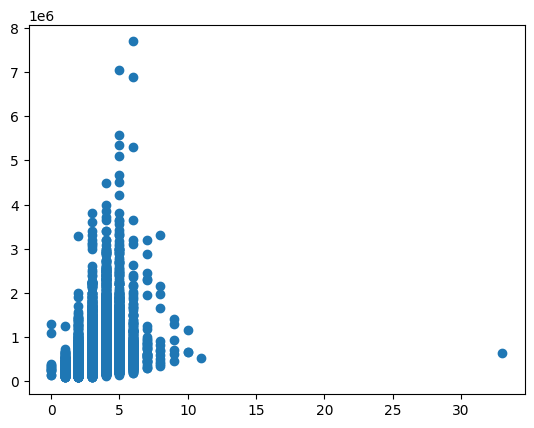

In [1360]:
plt.scatter(merge_casas_zipcode['bedrooms'], merge_casas_zipcode['price'])

Fui avisado de ante-mão sobre esse outlier extremo, então vou sumir com ele antes

In [1361]:
merge_casas_zipcode = merge_casas_zipcode[merge_casas_zipcode['bedrooms']<30]

<Axes: >

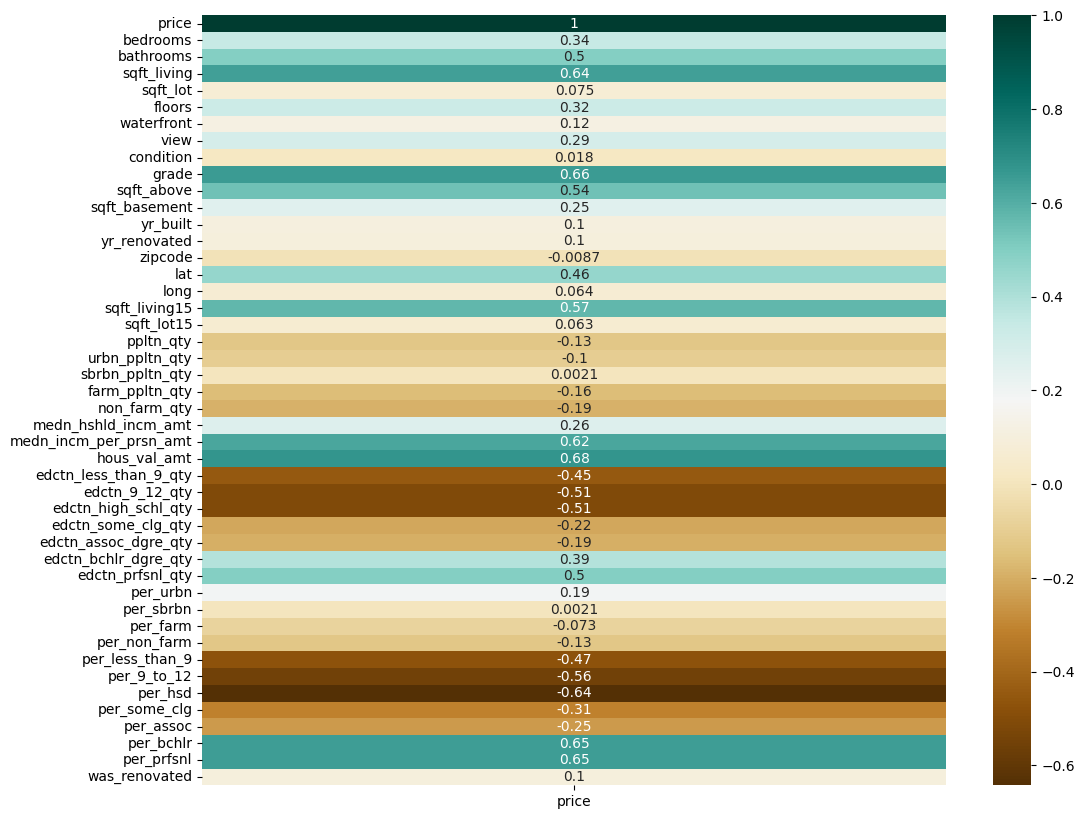

In [1362]:
# Sobre o método usado para calcular a correlação, apesar de algumas colunas serem lineares em relação ao preço, coisa que pearson assume que todas são,
#algumas colunas não possuem essa relação linear, então vou usar spearman que não assume nada.
corre = merge_casas_zipcode.corr('spearman')
plt.figure(figsize=(12,10))
sns.heatmap(corre[['price']], cmap='BrBG', annot=True)

<Axes: >

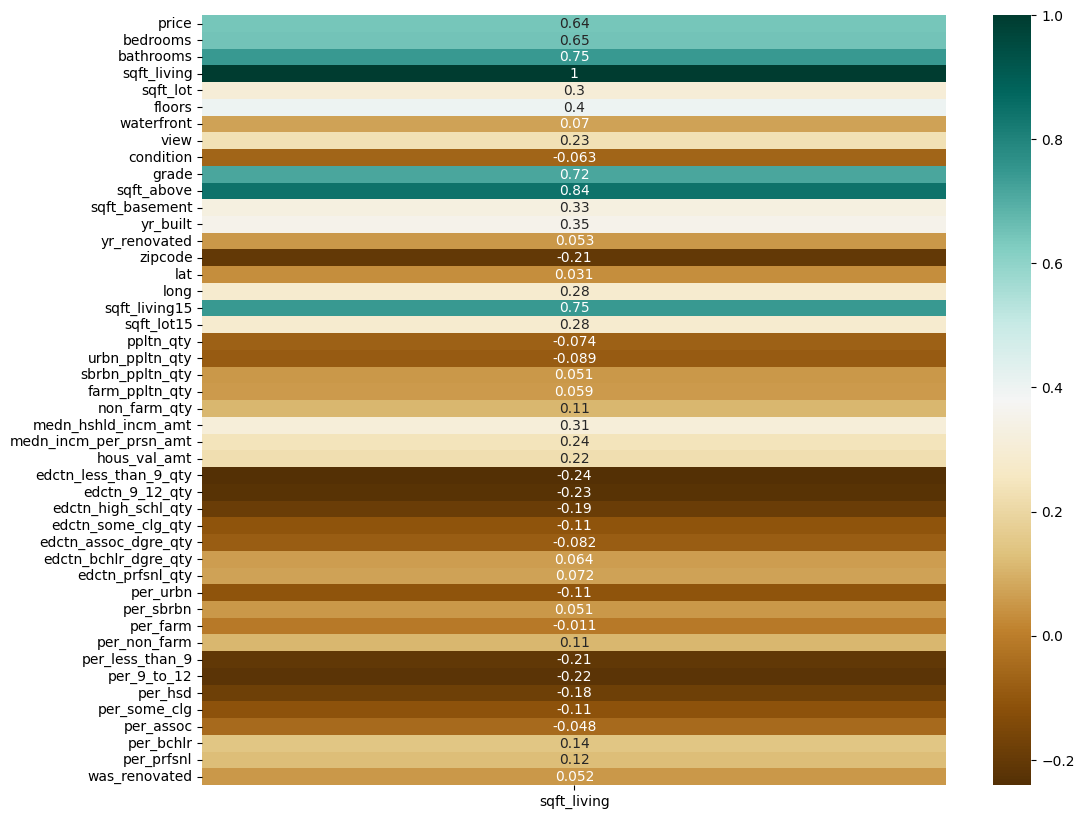

In [1363]:
# Para confirmar uma suspeita, vou plotar uma outra correlação
plt.figure(figsize=(12,10))
sns.heatmap(corre[['sqft_living']], cmap='BrBG', annot=True)

Dada a alta correlação, conseguimos afirmar que a coluna 'sqft_living' é a soma de 'sqft_above' e 'sqft_basement' e manter todas essas colunas geraria apenas uma multicolinearidade desnecessária, então vou mantar apenas 'sqft_living'.

#### Verificando scatterplot de todas as variáveis para verificar as relações

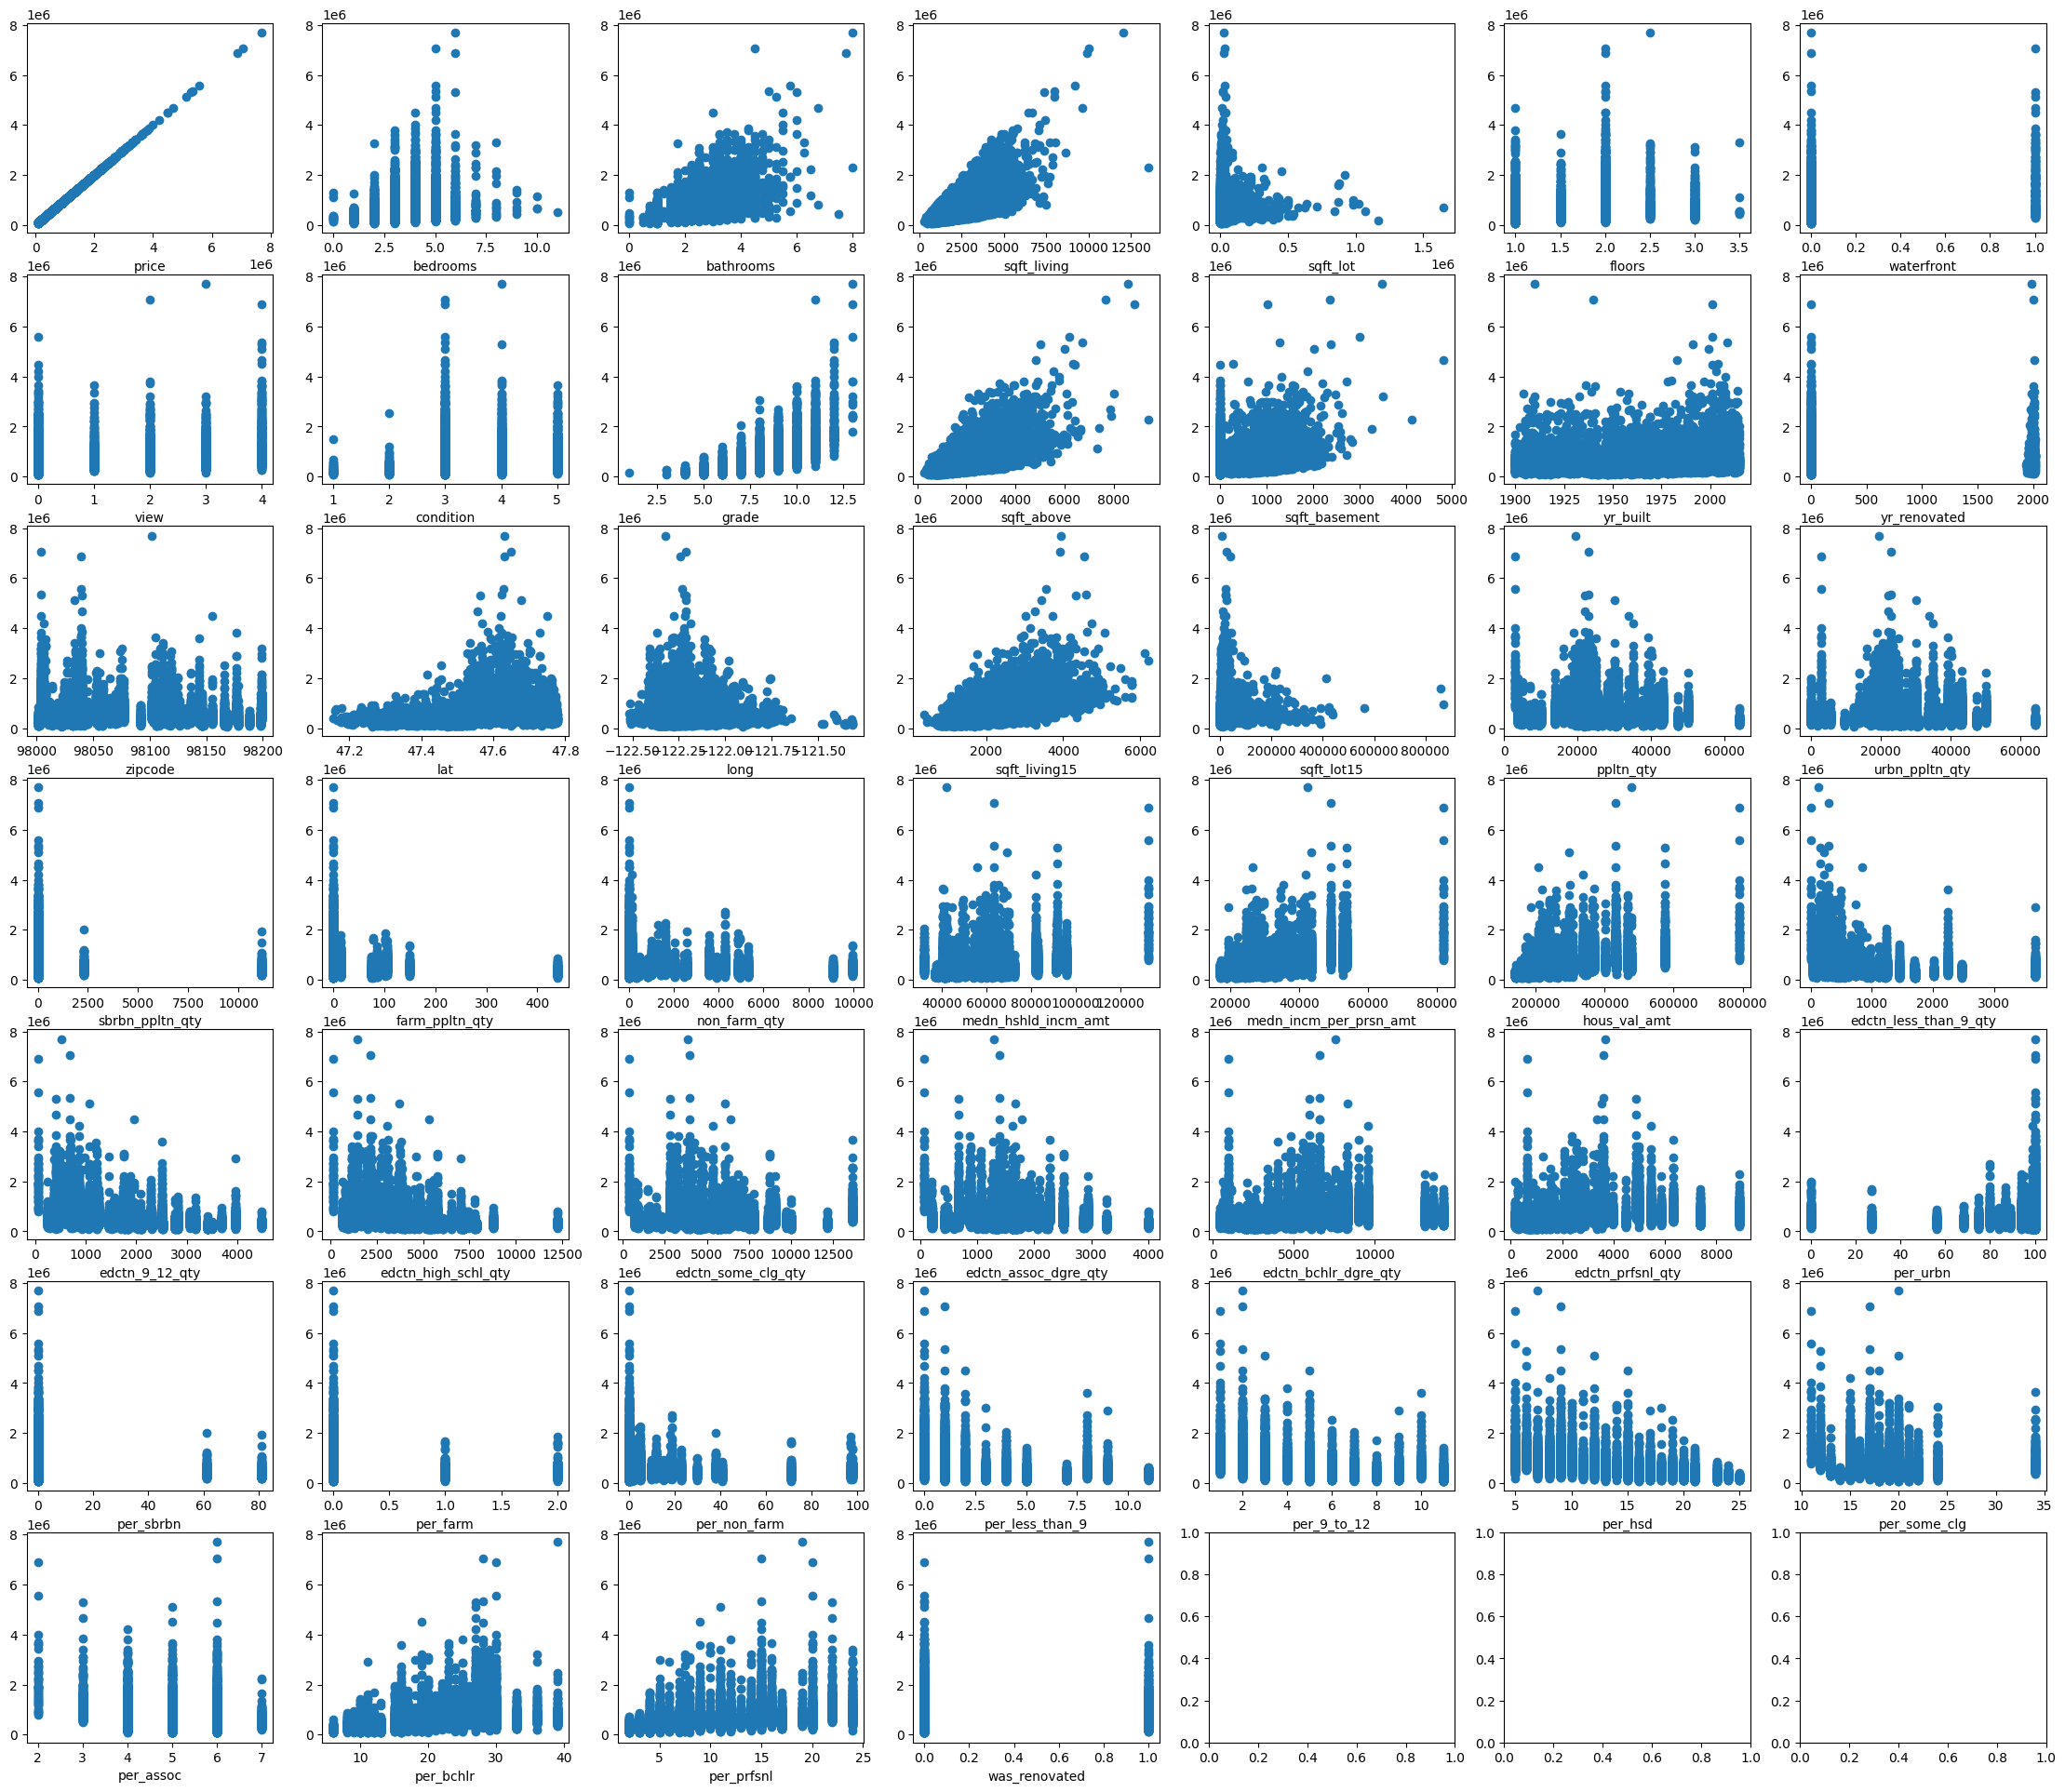

In [1364]:
colunas = merge_casas_zipcode.columns

fig, axes = plt.subplots(nrows=7, ncols=7, figsize=(28, 24))
for ax, coluna in zip(axes.flatten(), colunas):
    ax.scatter(merge_casas_zipcode[coluna], merge_casas_zipcode['price'])
    ax.set_xlabel(coluna)

#### Escolhendo as colunas pela correlação
Usarei todas as colunas que possuírem pelo menos 0,3 de correlação em módulo, já que a partir desse valor temos uma correlação considerada moderada e pode se dizer que possuímos uma associação entre as variáveis.

In [1365]:
colunas = corre['price'][abs(corre['price'])>0.3].index
colunas


Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'grade',
       'sqft_above', 'lat', 'sqft_living15', 'medn_incm_per_prsn_amt',
       'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty',
       'edctn_high_schl_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_bchlr', 'per_prfsnl'],
      dtype='object')

#### Removendo colunas redundantes e adicionando colunas importantes
- edctn_less_than_9_qty: Possuo o percentual disso, que além de possuir uma correlação maior, deixa a comparação entre CEPs mais justa
- edctn_9_12_qty: Mesmo raciocínio
- edctn_high_schl_qty: Mesmo raciocínio
- edctn_bchlr_dgre_qty: Mesmo raciocínio
- edctn_prfsnl_qty: Mesmo raciocínio
- long: coluna complementar de lat, não faz sentido na questão de localização eu ter uma e não ter a outra
- view: a correlação de view quase passa no critério(0.29) e é um critério importante de escolha de casa.

In [1366]:
colunas = colunas.drop(['edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'sqft_above'])
colunas = colunas.to_list() + ['long'] + ['view']
colunas

['price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'floors',
 'grade',
 'lat',
 'sqft_living15',
 'medn_incm_per_prsn_amt',
 'hous_val_amt',
 'per_less_than_9',
 'per_9_to_12',
 'per_hsd',
 'per_some_clg',
 'per_bchlr',
 'per_prfsnl',
 'long',
 'view']

In [1367]:
df = merge_casas_zipcode[colunas].copy()
df

,price,bedrooms,bathrooms,sqft_living,floors,grade,lat,sqft_living15,medn_incm_per_prsn_amt,hous_val_amt,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_bchlr,per_prfsnl,long,view
0,221900.0,3,1.00,1180,1.0,7,47.5112,1340,22158.0,175400.0,4.0,8.0,20.0,21.0,12.0,4.0,-122.257,0
1,538000.0,3,2.25,2570,2.0,7,47.7210,1690,25771.0,225900.0,2.0,5.0,15.0,20.0,20.0,12.0,-122.319,0
2,180000.0,2,1.00,770,1.0,6,47.7379,2720,31765.0,246600.0,1.0,4.0,13.0,20.0,19.0,9.0,-122.233,0
3,604000.0,4,3.00,1960,1.0,7,47.5208,1360,39232.0,280200.0,1.0,3.0,13.0,20.0,25.0,12.0,-122.393,0
4,510000.0,3,2.00,1680,1.0,8,47.6168,1800,27639.5,239850.0,1.0,5.0,15.0,19.0,19.0,7.5,-122.045,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,3.0,8,47.6993,1530,33122.0,279200.0,0.0,3.0,9.0,16.0,33.0,17.0,-122.346,0
21609,400000.0,4,2.50,2310,2.0,8,47.5107,1830,21789.0,180100.0,5.0,11.0,21.0,18.0,10.0,4.0,-122.362,0
21610,402101.0,2,0.75,1020,2.0,7,47.5944,1020,24751.0,219400.0,8.0,10.0,15.0,15.0,16.0,9.0,-122.299,0
21611,400000.0,3,2.50,1600,2.0,8,47.5345,1410,34109.0,308700.0,1.0,3.0,12.0,17.0,24.0,11.0,-122.069,0


### Mostre correlações, outliers e padrões relevantes.  


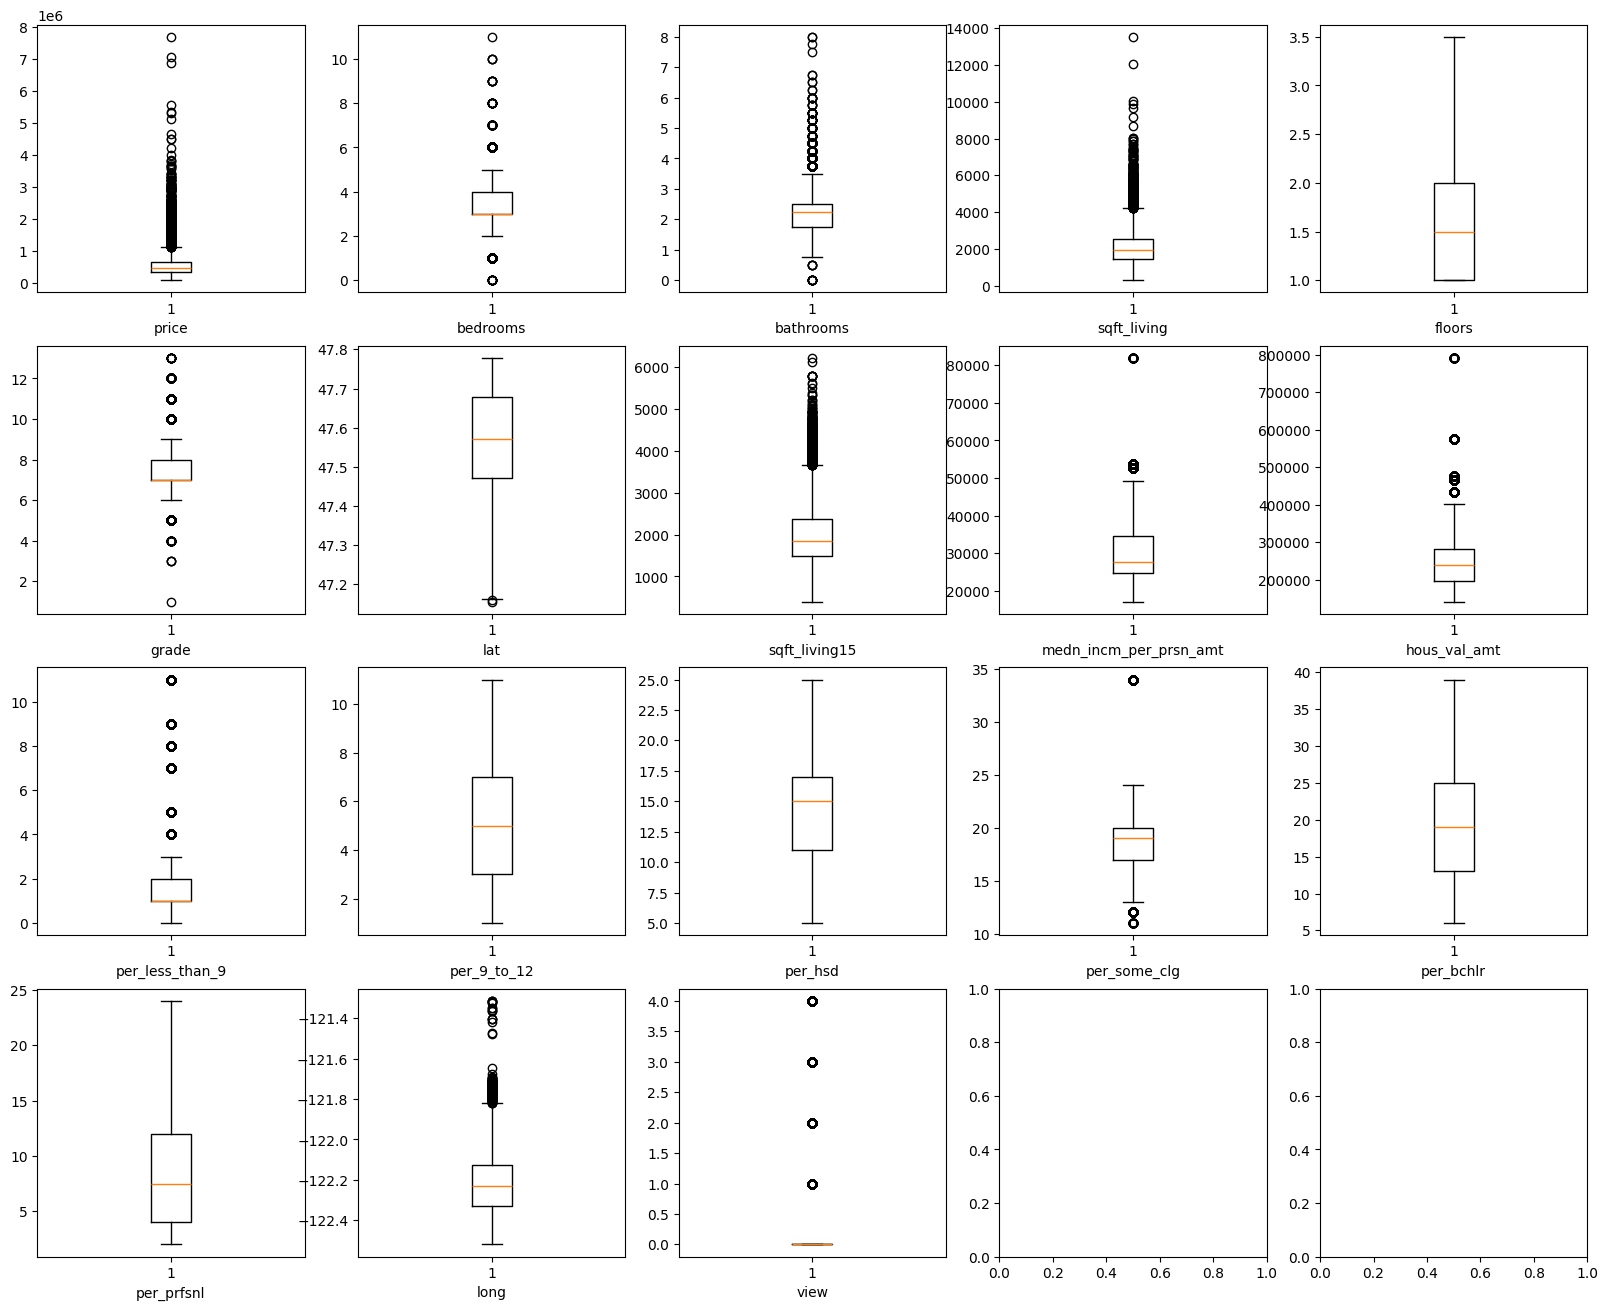

In [1368]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16))
for ax, coluna in zip(axes.flatten(), colunas):
    ax.boxplot(df[coluna])
    ax.set_xlabel(coluna)

In [1369]:
df['per_less_than_9'].value_counts()

,count
per_less_than_9,
1.0,8035
0.0,5103
2.0,3894
4.0,1435
3.0,1216
5.0,557
9.0,508
8.0,343
7.0,335


In [1370]:
df['per_some_clg'].value_counts()

,count
per_some_clg,
20.0,5533
19.0,4467
18.0,2687
15.0,2606
21.0,1698
17.0,1374
22.0,1064
16.0,874
13.0,321


In [1371]:
df['medn_incm_per_prsn_amt'].value_counts()

,count
medn_incm_per_prsn_amt,
27639.5,1254
33122.0,601
26547.0,590
34026.0,583
36862.0,574
...,...
42549.0,105
26315.0,100
26733.0,81


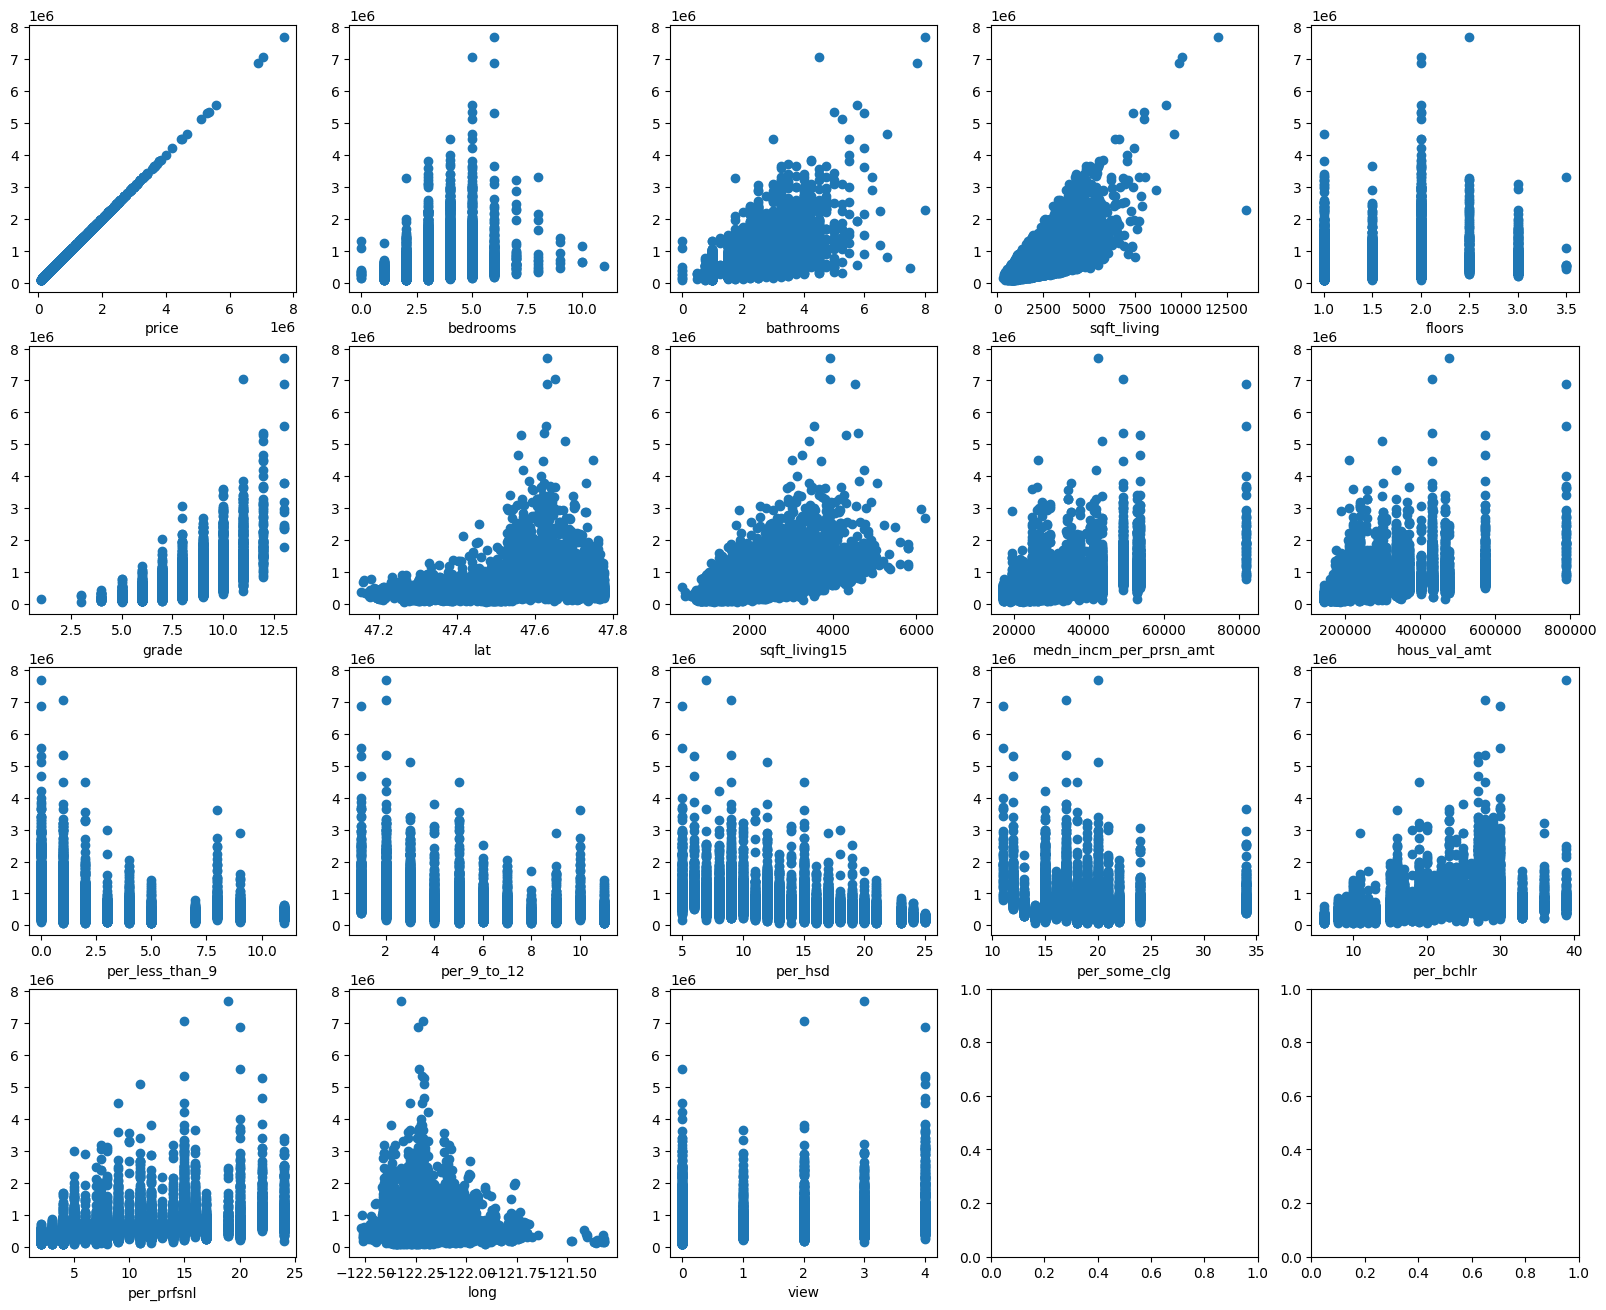

In [1372]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16))
for ax, coluna in zip(axes.flatten(), colunas):
    ax.scatter(df[coluna], df['price'])
    ax.set_xlabel(coluna)

#### Sobre os outliers
| Nome | O que fazer? |
| --- | --- |
| price | Devido a escala, vou aplicar um logaritmo para ficar mais perto e depois no resultado voltar com a exponencial |
| bedrooms | Remover o outlier extremo e manter o resto |
| bathrooms | Nada, são valores dentro do possível |
| sqft_living | Os outliers são valores factíveis pensando em mansões |
| floors | Não há |
| grade | Nada, são categorias |
| lat | Nada, como o dado precisa estar naquela forma, não vou mexer nele |
| sqft_living15 | Mesmo raciocínio de sqft_living |
| medn_incm_per_prsn_amt | Mesma coisa de price |
| hous_val_amt | Mesma coisa de price |
| per_less_than_9 | São valores factíveis |
| per_9_to_12 | Não há |
| per_hsd | Não há |
| per_some_clg | São valores factíveis |
| per_bchlr | Não há |
| per_prfsnl | Não há |
| long | Nada, como o dado precisa estar naquela forma, não vou mexer nele |
| view | Como é uma variável categórica, vou deixar como está |

## 2. Desenvolvimento do modelo de Machine Learning

- **a. Variáveis importantes:** quais features foram mais relevantes e por quê.
  -   Já foi justificado anteriormente pelo uso de correlação

### Divisão do dataset e Padronização

In [1373]:
df['price'] = np.log(df['price'])
df['medn_incm_per_prsn_amt'] = np.log(df['medn_incm_per_prsn_amt'])
df['hous_val_amt'] = np.log(df['hous_val_amt'])
df

,price,bedrooms,bathrooms,sqft_living,floors,grade,lat,sqft_living15,medn_incm_per_prsn_amt,hous_val_amt,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_bchlr,per_prfsnl,long,view
0,12.309982,3,1.00,1180,1.0,7,47.5112,1340,10.005954,12.074824,4.0,8.0,20.0,21.0,12.0,4.0,-122.257,0
1,13.195614,3,2.25,2570,2.0,7,47.7210,1690,10.157005,12.327848,2.0,5.0,15.0,20.0,20.0,12.0,-122.319,0
2,12.100712,2,1.00,770,1.0,6,47.7379,2720,10.366120,12.415523,1.0,4.0,13.0,20.0,19.0,9.0,-122.233,0
3,13.311329,4,3.00,1960,1.0,7,47.5208,1360,10.577248,12.543259,1.0,3.0,13.0,20.0,25.0,12.0,-122.393,0
4,13.142166,3,2.00,1680,1.0,8,47.6168,1800,10.227001,12.387769,1.0,5.0,15.0,19.0,19.0,7.5,-122.045,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,12.793859,3,2.50,1530,3.0,8,47.6993,1530,10.407953,12.539684,0.0,3.0,9.0,16.0,33.0,17.0,-122.346,0
21609,12.899220,4,2.50,2310,2.0,8,47.5107,1830,9.989161,12.101268,5.0,11.0,21.0,18.0,10.0,4.0,-122.362,0
21610,12.904459,2,0.75,1020,2.0,7,47.5944,1020,10.116621,12.298652,8.0,10.0,15.0,15.0,16.0,9.0,-122.299,0
21611,12.899220,3,2.50,1600,2.0,8,47.5345,1410,10.437317,12.640125,1.0,3.0,12.0,17.0,24.0,11.0,-122.069,0


In [1374]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'grade',
       'lat', 'sqft_living15', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_bchlr', 'per_prfsnl', 'long', 'view'],
      dtype='object')

#### Sobre padronização

Para padronizar irei usar o Standard Scaler, uma vez que meu modelo não tem outliers extremos.

| Nome | O que fazer? |
| --- | --- |
| price | Coluna alvo |
| bedrooms | Padronizar |
| bathrooms | Padronizar |
| sqft_living | Padronizar |
| floors | Padronizar |
| grade | Padronizar |
| lat | Padronizar |
| sqft_living15 | Padronizar |
| medn_incm_per_prsn_amt | Padronizar |
| hous_val_amt | Padronizar |
| per_less_than_9 | Padronizar |
| per_9_to_12 | Padronizar |
| per_hsd | Padronizar |
| per_some_clg | Padronizar |
| per_bchlr | Padronizar |
| per_prfsnl | Padronizar |
| long | Padronizar |
| view | Padronizar |

In [1375]:
X = df.drop(columns=['price'], axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [1376]:
standard = StandardScaler()
standard.fit(X_train, y_train)

StandardScaler()

In [1377]:
X_train = standard.transform(X_train)
X_test = standard.transform(X_test)

- **b. Escolha do modelo:** escolha e implemente um modelo para resolver o problema --- Lembre-se que a NP1 englobou até MLP.
  - Irei usar MLP para o treinamento, visto que a MLP consegue pegar tanto padrões não lineares quanto padrões lineares. Minhas features possuem ambos, então a MLP se encaixa bem.

In [1378]:
tf.keras.backend.clear_session()

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(17,), name='Entrada'),
        tf.keras.layers.Dense(256, activation='relu', name='Dense1'),
        tf.keras.layers.Dense(128, activation='relu', name='Dense2'),
        tf.keras.layers.Dense(64, activation='relu', name='Dense3'),
        tf.keras.layers.Dense(32, activation='relu', name='Dense4'),
        tf.keras.layers.Dense(1, activation=None, name='Saida')
    ]
)

Sobre as camadas: Quantidade de camadas e neurônios atual foi resultado de tentativas recorrentes de diferentes valores. Nos modelos anteriores o R²Score final girava em torno de 74% a 82% e, com os valores atuais, a arquitetura atual conseguiu atingir 84,5% de R²Score.

In [1379]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense1 (Dense)                  │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense4 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,873 (187.00 KB)

 Trainable params: 47,873 (187.00 KB)

 Non-trainable params: 0 (0.00 B)

In [1380]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics = [tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.R2Score(), tf.keras.metrics.RootMeanSquaredError()]
)

In [1381]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15
)

history = model.fit(
    x = X_train, y = y_train,
    epochs = 150,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 7.6960 - mean_squared_error: 7.6960 - r2_score: -26.9690 - root_mean_squared_error: 2.7742 - val_loss: 0.6689 - val_mean_squared_error: 0.6689 - val_r2_score: -1.4332 - val_root_mean_squared_error: 0.8178
Epoch 2/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3106 - mean_squared_error: 0.3106 - r2_score: -0.1289 - root_mean_squared_error: 0.5574 - val_loss: 0.1735 - val_mean_squared_error: 0.1735 - val_r2_score: 0.3688 - val_root_mean_squared_error: 0.4165
Epoch 3/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0988 - mean_squared_error: 0.0988 - r2_score: 0.6411 - root_mean_squared_error: 0.3142 - val_loss: 0.0808 - val_mean_squared_error: 0.0808 - val_r2_score: 0.7061 - val_root_mean_squared_error: 0.2842
Epoch 4/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0746 - mean_squared_error: 0.0746 - r2_score: 0.7290 - root_mean_squared_error: 0.2731 - val_loss: 0.0633 - val_mean_squared_error: 0.0633 - val

In [1382]:
loss, mse, r2, rmse = model.evaluate(X_test,y_test)
print(f'Loss do modelo: {loss}')
print(f'R² do modelo: {r2}')

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0441 - mean_squared_error: 0.0441 - r2_score: 0.8455 - root_mean_squared_error: 0.2101
Loss do modelo: 0.04414305463433266
R² do modelo: 0.8455283641815186


Pelo valor do R², o modelo consegue explicar cerca de 84,9% da variação dos dados dos valores das casas.

Text(0.5, 1.0, 'Loss nos conjuntos de treino e validação')

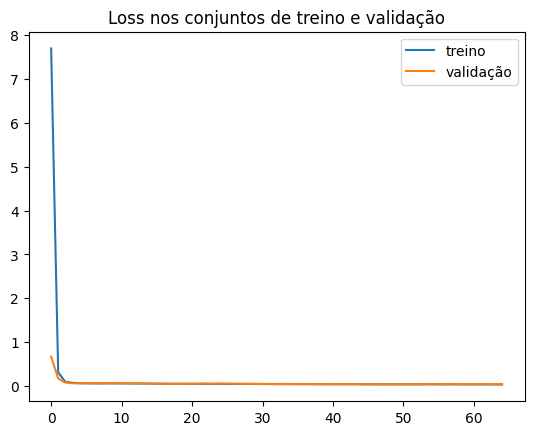

In [1383]:
plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label = 'validação')
plt.legend()
plt.title('Loss nos conjuntos de treino e validação')

Text(0.5, 1.0, 'R²-Score nos conjuntos para a MLP')

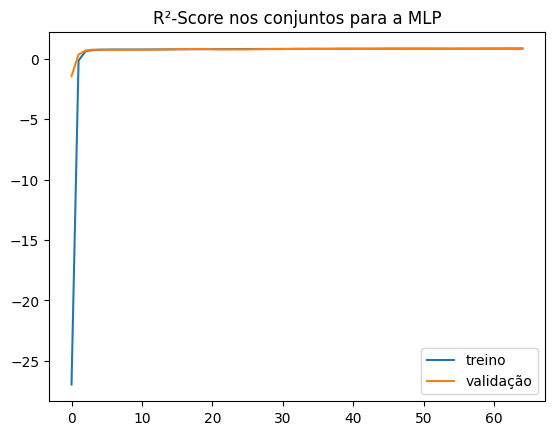

In [1384]:
plt.plot(history.history['r2_score'], label='treino')
plt.plot(history.history['val_r2_score'], label = 'validação')
plt.legend()
plt.title('R²-Score nos conjuntos para a MLP')

### Testando hipótese de hous_val_amt
Como mencionado no início, 'hous_val_amt' é uma feature que é próxima o suficiente de 'price' ao ponto de que poderia levá-lo ao overfitting ou ajudá-lo, então, foi proposto o treinamento de um modelo sem essa feature para testar

In [1385]:
df_hip = df.drop('hous_val_amt', axis=1)
df_hip.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'grade',
       'lat', 'sqft_living15', 'medn_incm_per_prsn_amt', 'per_less_than_9',
       'per_9_to_12', 'per_hsd', 'per_some_clg', 'per_bchlr', 'per_prfsnl',
       'long', 'view'],
      dtype='object')

In [1386]:
X_hip = df_hip.drop(columns=['price'], axis=1)
y_hip = df_hip['price']
X_train_hip, X_test_hip, y_train_hip, y_test_hip = train_test_split(X_hip, y_hip,test_size=0.2, random_state=42)

In [1387]:
standard_hip = StandardScaler()
standard_hip.fit(X_train_hip, y_train_hip)
X_train_hip = standard_hip.transform(X_train_hip)
X_test_hip = standard_hip.transform(X_test_hip)

In [1388]:
tf.keras.backend.clear_session()

model_hip = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(16,), name='Entrada'),
        tf.keras.layers.Dense(256, activation='relu', name='Dense1'),
        tf.keras.layers.Dense(128, activation='relu', name='Dense2'),
        tf.keras.layers.Dense(64, activation='relu', name='Dense3'),
        tf.keras.layers.Dense(32, activation='relu', name='Dense4'),
        tf.keras.layers.Dense(1, activation=None, name='Saida')
    ]
)

In [1389]:
model_hip.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics = [tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.R2Score(), tf.keras.metrics.RootMeanSquaredError()]
)

In [1390]:
history_hip = model_hip.fit(
    x = X_train_hip, y = y_train_hip,
    epochs = 150,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.7549 - mean_squared_error: 8.7549 - r2_score: -30.8172 - root_mean_squared_error: 2.9589 - val_loss: 0.5863 - val_mean_squared_error: 0.5863 - val_r2_score: -1.1327 - val_root_mean_squared_error: 0.7657
Epoch 2/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2699 - mean_squared_error: 0.2699 - r2_score: 0.0190 - root_mean_squared_error: 0.5196 - val_loss: 0.2084 - val_mean_squared_error: 0.2084 - val_r2_score: 0.2419 - val_root_mean_squared_error: 0.4565
Epoch 3/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0937 - mean_squared_error: 0.0937 - r2_score: 0.6596 - root_mean_squared_error: 0.3061 - val_loss: 0.0889 - val_mean_squared_error: 0.0889 - val_r2_score: 0.6765 - val_root_mean_squared_error: 0.2982
Epoch 4/150
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0737 - mean_squared_error: 0.0737 - r2_score: 0.7321 - root_mean_squared_error: 0.2715 - val_loss: 0.0634 - val_mean_squared_error: 0.0634 - val_

In [1391]:
loss, mse, r2, rmse = model_hip.evaluate(X_test_hip, y_test_hip)
print(f'Loss no modelo sem a coluna: {loss}')
print(f'R² no modelo sem a coluna: {r2}')

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0532 - mean_squared_error: 0.0532 - r2_score: 0.8137 - root_mean_squared_error: 0.2308
Loss no modelo sem a coluna: 0.0532459057867527
R² no modelo sem a coluna: 0.8136743307113647


Dado a diferença de cerca de 3,2% no R² em comparação ao modelo que tinha a coluna 'hous_val_amt', pode-se concluir que a coluna é importante para o modelo conseguir generalizar os dados e não um impeditivo que o levaria ao overfitting, logo, o modelo final que será usado será o que o usou para ser treinado.

### Prevendo os valores do dataset Future Unseen

In [1392]:
merge_unseen_zipcode = future_unseen.merge(zipcode, on='zipcode')
merge_unseen_zipcode

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl
0,4,1.00,1680,5043,1.5,0,0,4,6,1680,...,0.0,0.0,0.0,9.0,9.0,17.0,15.0,4.0,11.0,6.0
1,3,2.50,2220,6380,1.5,0,0,4,8,1660,...,0.0,0.0,0.0,0.0,2.0,8.0,15.0,4.0,30.0,20.0
2,3,2.25,1630,10962,1.0,0,0,4,8,1100,...,0.0,0.0,0.0,1.0,5.0,15.0,19.0,5.0,19.0,7.5
3,5,2.50,1710,9720,2.0,0,0,4,8,1710,...,0.0,0.0,0.0,2.0,3.0,10.0,17.0,4.0,26.0,16.0
4,2,1.00,850,6370,1.0,0,0,3,6,850,...,0.0,0.0,0.0,4.0,7.0,16.0,19.0,5.0,16.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3,2.50,2430,54059,2.0,0,0,3,10,2430,...,0.0,0.0,19.0,1.0,3.0,12.0,17.0,6.0,24.0,11.0
96,2,2.50,1240,1249,3.0,0,0,3,8,1240,...,0.0,0.0,0.0,1.0,5.0,14.0,20.0,5.0,28.0,11.0
97,4,1.75,1860,9750,1.0,0,0,3,7,1460,...,0.0,0.0,0.0,1.0,4.0,14.0,21.0,6.0,20.0,8.0
98,5,1.75,2330,3800,1.5,0,0,3,7,1360,...,0.0,0.0,0.0,0.0,2.0,8.0,15.0,4.0,30.0,20.0


In [1393]:
colunas.remove('price')
previsao = merge_unseen_zipcode[colunas].copy()
previsao

,bedrooms,bathrooms,sqft_living,floors,grade,lat,sqft_living15,medn_incm_per_prsn_amt,hous_val_amt,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_bchlr,per_prfsnl,long,view
0,4,1.00,1680,1.5,6,47.5354,1560,19414.0,187300.0,9.0,9.0,17.0,15.0,11.0,6.0,-122.273,0
1,3,2.50,2220,1.5,8,47.6974,950,34026.0,282800.0,0.0,2.0,8.0,15.0,30.0,20.0,-122.313,0
2,3,2.25,1630,1.0,8,47.3801,1830,27639.5,239850.0,1.0,5.0,15.0,19.0,19.0,7.5,-122.166,0
3,5,2.50,1710,2.0,8,47.5903,2270,36019.0,343500.0,2.0,3.0,10.0,17.0,26.0,16.0,-122.157,0
4,2,1.00,850,1.0,6,47.5198,850,25844.0,200000.0,4.0,7.0,16.0,19.0,16.0,7.0,-122.373,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3,2.50,2430,2.0,10,47.4664,2910,34109.0,308700.0,1.0,3.0,12.0,17.0,24.0,11.0,-121.992,0
96,2,2.50,1240,3.0,8,47.6718,1240,28918.0,255400.0,1.0,5.0,14.0,20.0,28.0,11.0,-122.386,0
97,4,1.75,1860,1.0,7,47.7097,1900,29747.0,239900.0,1.0,4.0,14.0,21.0,20.0,8.0,-122.202,0
98,5,1.75,2330,1.5,7,47.6835,2100,34026.0,282800.0,0.0,2.0,8.0,15.0,30.0,20.0,-122.308,0


In [1394]:
previsao['medn_incm_per_prsn_amt'] = np.log(previsao['medn_incm_per_prsn_amt'])
previsao['hous_val_amt'] = np.log(previsao['hous_val_amt'])
previsao[['hous_val_amt', 'medn_incm_per_prsn_amt']]

,hous_val_amt,medn_incm_per_prsn_amt
0,12.140467,9.873750
1,12.552495,10.434880
2,12.387769,10.227001
3,12.746942,10.491802
4,12.206073,10.159834
...,...,...
95,12.640125,10.437317
96,12.450586,10.272220
97,12.387977,10.300484
98,12.552495,10.434880


In [1395]:
previsao_normalizada = standard.transform(previsao)

In [1396]:
previsao_resultado = np.exp(model.predict(previsao_normalizada))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [1397]:
previsao_resultado

array([[ 304476.  ],
       [ 533338.5 ],
       [ 286666.66],
       [ 621081.9 ],
       [ 274977.75],
       [ 513724.12],
       [ 298904.88],
       [ 432133.16],
       [1044498.94],
       [ 573784.25],
       [ 435020.16],
       [ 408436.88],
       [ 484366.97],
       [ 267707.22],
       [ 819320.75],
       [ 211185.73],
       [ 414123.66],
       [ 649732.2 ],
       [ 506309.72],
       [ 311139.3 ],
       [ 437731.84],
       [ 692212.4 ],
       [ 426803.88],
       [ 336316.56],
       [ 258443.88],
       [ 371117.5 ],
       [ 703821.5 ],
       [ 277297.3 ],
       [ 226212.55],
       [ 376956.  ],
       [ 284096.7 ],
       [ 960264.75],
       [1025881.25],
       [ 496208.2 ],
       [ 280691.25],
       [ 330761.28],
       [ 318748.7 ],
       [ 699768.44],
       [ 177781.8 ],
       [ 241249.31],
       [ 206643.33],
       [ 917795.3 ],
       [ 370991.16],
       [ 292751.12],
       [ 251973.08],
       [ 269162.3 ],
       [ 314418.03],
       [ 8215

- **c. Generalização:** como você garante que o modelo generaliza bem para novos dados (ex: uso de *train/test split*, *cross-validation*, regularização, etc.).
  - Garanti a generalização através do uso de train/test split para dividir o dataset em 80% para treino e 20% para teste e depois no uso da MLP usei 20% do conjunto de treino como validação. Além disso, o método de EarlyStopping para a MLP foi utilizado para fazer com que o modelo pare antes de entrar em overfitting, o que ajuda o modelo a generalizar sem decorar os dados. Somado a isso, o plot dos gráficos de loss e R² para o conjunto de validação e treino mostram que ambos os conjuntos possuem métricas próximas, o que indica que o modelo está generalizando bem para ambos e não apenas para o conjunto de treino, o que indica que ele não está em overfitting.